# 🎲 Introducción a la Simulación

Una **simulación** es un proceso en el que usamos un computador para imitar fenómenos reales o aleatorios. Esto nos permite analizar situaciones repetitivas o inciertas sin realizar experimentos físicos.

Aquí te presentamos una guía básica para construir simulaciones en Python.

---

## 🧭 Pasos para realizar una simulación

- 1. ¿Qué queremos simular?

Primero define claramente el experimento.  
Por ejemplo: *¿Qué sucede al lanzar una moneda?* Los posibles resultados serían `'cara'` o `'sello'`.

- 2. ¿Cómo simular un solo valor?

Diseña una forma de generar **un resultado aleatorio**.  
Por ejemplo, para una moneda:
```python
np.random.choice(['cara', 'sello'])
```

- 3. ¿Cuántas veces repetiremos el experimento?

Decide cuántas veces ejecutarás la simulación.

Por ejemplo: *simular 1000 lanzamientos de moneda* te permitirá observar con mayor claridad la frecuencia relativa de cada resultado (`'cara'` o `'sello'`).



4. ¿Cómo simular múltiples valores y almacenarlos?
Sigue estos pasos:

- Crea una lista vacía para almacenar los resultados.
- Usa un bucle for para repetir la simulación la cantidad de veces que necesites.

- En cada repetición:
    Simula un valor aleatorio.
    Guarda el valor en la lista.

5. ¿Cómo analizar los resultados?
Una vez tengas los resultados:

-  Crea una tabla con Table().with_column('Resultado', resultados)
- Agrupa por resultado con .group('Resultado') para contar frecuencias
- Visualiza los resultados con .bar('Resultado') para ver la distribución
- Calcula proporciones u otros estadísticos según el caso

Referencia: https://inferentialthinking.com/chapters/09/3/Simulation.html#

In [1]:
import numpy as np
from datascience import *
import matplotlib.pylab as plots
plots.style.use('fivethirtyeight')
%matplotlib inline


In [2]:
moneda = make_array("tail", "head")
moneda

array(['tail', 'head'],
      dtype='<U4')

In [3]:
def simulacion_lanzamiento():
    lanzamientos =  np.random.choice(moneda, 100)
    return np.count_nonzero(lanzamientos=="head")
    return np.random.choice(moneda)

In [4]:
lanzamientos=make_array()
for i in range(0, 100):
    lanzamientos = np.append(lanzamientos,simulacion_lanzamiento()    )

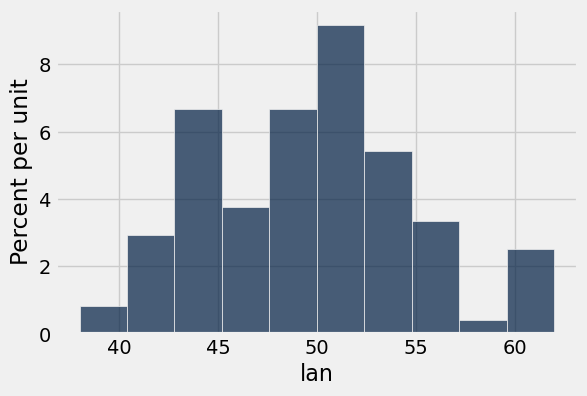

In [5]:
mon = Table().with_columns("lan",lanzamientos)

mon.hist()

# Problema The monty hall 


<img src="Fig0.png" alt="Descripción de la imagen" style="width: 500px;"/>

El problema de Monty Hall es un clásico de la teoría de probabilidades y es famoso por ilustrar cómo la intuición humana a menudo puede llevar a conclusiones incorrectas acerca de las probabilidades. Está basado en un programa de concursos televisivo llamado "Let’s Make a Deal", que fue presentado por Monty Hall. A continuación se presenta una introducción guía al problema:

### Descripción del Problema:

Imagina que participas en un concurso donde se te presenta una elección entre tres puertas. Detrás de una de estas puertas hay un premio muy deseado, como un coche, y detrás de las otras dos puertas hay un premio indeseado, como una cabra.

**Pasos del Concurso:**
1. **Elección Inicial:** Primero, se te pide que elijas una de las tres puertas.
2. **Apertura del Presentador:** Luego de que elijas una puerta, el anfitrión (quien sabe lo que hay detrás de todas las puertas) abrirá una de las otras dos puertas, revelando una cabra.
3. **Segunda Elección:** Ahora tienes la opción de quedarte con tu elección inicial o cambiar a la otra puerta restante.

### La Cuestión:

La pregunta fundamental que plantea el problema es: ¿Deberías cambiar tu elección o quedarte con tu elección inicial para maximizar tus posibilidades de ganar el coche?
----------------

# Algoritmo 

1. Definir el estado inicial, como van estar las puertas, con las cabras y el carro.
2. Esta elección puede estar de forma aleatoria
3. Tomar la eleccion del concursante.
4. Si eleccion del concursante == Cabra 1
    eleccion del concursante, Cabra 2, Carro
4. Si no, si: eleccion del concursante == Cabra 2
    eleccion del concursante, Cabra 1, Carro
5. Si no, si :eleccion del concursante == Carro
   carro, cabra 1, cabra 2


Lo anterior puede ser definido dentro de una función y repetido N-veces


In [6]:
from IPython.display import YouTubeVideo
from datascience import *
import numpy as np
import matplotlib.pylab as plots
plots.style.use('fivethirtyeight')
%matplotlib inline


In [7]:
# Minuto  1:20
YouTubeVideo("https://www.youtube.com/watch?v=uz58hg0EJAY")

In [56]:
def estado_inicial():
    puertas = make_array("Bob", "Alice", "Carro")
    np.random.shuffle(puertas)
    return puertas

array(['Carro', 'Bob', 'Alice'],
      dtype='<U5')

In [185]:
def un_experimento():
    state = estado_inicial()
    eleccion = np.random.choice(state)
    if eleccion=="Bob":
        revelada="Alice"
        otro_objeto="Carro"
      #  print(revelada)   
    elif eleccion=="Alice":
        revelada="Bob"
        otro_objeto="Carro"
     #   print(revelada)
    elif eleccion=="Carro":
        c = make_array("Bob", "Alice")
        revelada = np.random.choice(c)
        if revelada=="Bob":
            otro_objeto="Alice"
        elif revelada=="Alice":
            otro_objeto="Bob"
    # Eleccion participante, Revelada, Otra_objeto
    return make_array(eleccion, revelada, otro_objeto)

In [211]:
monty_hall = Table(["Eleccion", "Reveleda", "OtroObjeto"])
for i in range(0,100):
    a=un_experimento()
    monty_hall=monty_hall.append(a)

In [221]:
monty_hall

Eleccion,Reveleda,OtroObjeto
Carro,Bob,Alice
Carro,Bob,Alice
Bob,Alice,Carro
Alice,Bob,Carro
Alice,Bob,Carro
Alice,Bob,Carro
Alice,Bob,Carro
Alice,Bob,Carro
Carro,Alice,Bob
Carro,Bob,Alice


In [224]:
monty_hall

Eleccion,Reveleda,OtroObjeto
Carro,Bob,Alice
Carro,Bob,Alice
Bob,Alice,Carro
Alice,Bob,Carro
Alice,Bob,Carro
Alice,Bob,Carro
Alice,Bob,Carro
Alice,Bob,Carro
Carro,Alice,Bob
Carro,Bob,Alice


In [222]:
monty_hall.where("Eleccion", are.containing("Carro")).group("Eleccion")

Eleccion,count
Carro,44


In [225]:
monty_hall.where("OtroObjeto", are.containing("Carro")).group("OtroObjeto")

OtroObjeto,count
Carro,56


In [169]:
c[~(c==revelada)]

array(['Alice'],
      dtype='<U5')

In [128]:
state = estado_inicial()
print(state)
eleccion = np.random.choice(state)
print(eleccion)
reveleda=presentador(eleccion)
print(revelada)

['Alice' 'Carro' 'Bob']
Alice
Alice


In [ ]:
1. Elegir ua puerta participante
    Supongamos que elige la puerta 1

2. Presentar revela la cabra que hay en las 2 puertas faltantes
    cabra_revelada
3. if participate cambia:
      eleccion 
4. else mantiene:
     eleccion

Adivinar,count
Cabra A,308
Cabra B,361
Carro,331


OtraOpcion,count
Cabra A,168
Cabra B,163
Carro,669
